# Blazar Population ML – Part 2: Baryon Loading Regression (MOJAVE Cross-Match)

---

[Part 1](./blazar_population_ml-p1.ipynb) established the cluster geometry of the full 4LAC-DR3 blazar population and assigned probabilistic classifications to BCU sources using unsupervised methods. Part 2 shifts to the supervised regression task: given the 334-source MOJAVE-matched subsample, can a model recover the baryon loading constraint $50 \lesssim \mu \lesssim 80$ derived by Rueda-Becerril, Harrison & Giannios (2021) from purely observational features?

The feature set expands beyond Part 1. Appended kinematic observables $\beta_{\rm app}$ and $\Gamma_{\rm min} = \sqrt{1 + \beta_{\rm app}^2}$ from MOJAVE-XVII (Lister et al. 2021) are the same quantities used in the forward model of the 2021 paper. This is the direct observational link between the simulation constraints and the data-driven approach.

**Scientific question:** Does a Gaussian Process Regression model trained on $\{\log \nu_{\rm syn},\, A_C,\, \Gamma_{\rm min},\, \ldots\}$ recover a $\mu$ distribution consistent with $[50, 80]$ across the MOJAVE subsample? Agreement validates the 2021 result in a fully data-driven setting. Disagreement is informative: it constrains which features carry the baryon loading signal and where the 2021 model assumptions break down.

---

## Baryon Loading and Jet Composition

The physical composition of relativistic jets is a fundamental unsolved problem in high-energy astrophysics. Whether jets are dominated by electron-positron pairs or carry a significant hadronic component determines their total kinetic power and efficiency as particle accelerators, but this hadronic content cannot be measured directly. It must be inferred through a combination of radiative modeling and kinematic observations.

The key parameter is the **baryon loading** $\mu$, defined as the total energy flux per unit rest-mass energy flux of the jet (e.g., Komissarov et al. 2007):

$$\mu := \Gamma(1 + \sigma)$$

where $\Gamma$ is the bulk Lorentz factor and $\sigma$ is the jet magnetization, defined as the ratio of Poynting flux to hydrodynamic energy flux. A jet with $\mu \approx 1$ would be nearly magnetically dominated, while larger $\mu$ means more energy per baryon is available for acceleration and radiation. According to magnetohydrodynamic (MHD) theory, $\mu$ is conserved along the jet during magnetic acceleration: as $\Gamma$ increases, $\sigma$ decreases proportionally, leaving $\mu$ imprinted by the launch conditions near the black hole. Constraining $\mu$ from observations is therefore a direct probe of the jet formation mechanism.

In Rueda-Becerril et al. (2021), the authors propose and test a simple physical picture: all blazar jets are launched with similar energy per baryon, that is, $\mu$ is approximately constant across the entire blazar population regardless of jet power or accretion rate. The accretion rate $\dot{m}$ (in Eddington units) connects the bulk Lorentz factor and the jet luminosity through an empirical power-law relation motivated by VLBI observations ($\dot{m} \propto \Gamma^s$), effectively parameterizing the full SED by a single observable. Within this framework:

- **FSRQs** correspond to high $\dot{m}$. Their jets achieve large $\Gamma$ but settle at low magnetization ($\sigma \lesssim 10$) at the emission region. Magnetic reconnection injects a steep particle energy distribution ($p \gtrsim 2$), producing soft $\gamma$-ray spectra. The dense external photon field from the BLR drives EC emission, pushing Compton dominance to values well above unity and $\nu_{\rm syn}$ to low frequencies.
- **BL Lacs** correspond to low $\dot{m}$. Their jets do not reach large $\Gamma$, leaving the emission region more strongly magnetized ($\sigma \gtrsim 10$). Reconnection produces a hard particle spectrum ($p \lesssim 2$) and hard $\gamma$-ray emission at $\gtrsim$ GeV. The faint or absent BLR means SSC dominates, keeping $\nu_{\rm syn}$ at high frequencies and Compton dominance near or below unity.

---

## This Project: Machine Learning Extension

Rueda-Becerril et al. (2021) established the population-level result: a constant baryon loading $\mu \approx 50\text{--}80$ is consistent with all blazar observables. What it did not provide is a source-by-source estimation of $\mu$ or a scalable method for classifying the thousands of catalog sources that lack individual SED modeling. This project addresses both gaps using classical machine learning on two observational datasets: the full 4LAC-DR3 catalog and the MOJAVE-XVII VLBI survey.

This first stage of the project will consist of two parts:

- **Part 1 (full catalog, ~3,400 sources):** catalog-native SED and spectral features only, no kinematics
- **Part 2 (MOJAVE cross-matched, ~334 sources):** adds $\beta_{\rm app}$ and $\Gamma_{\rm min}$

In this notebook we address the second part of the project. Using the numerical code [`Tleco`](https://github.com/zkdavis/Tleco) to solve the Fokker-Planck equation for the evolving electron distribution and compute synchrotron, SSC, and EC emission, the authors generate synthetic SEDs across a grid of magnetization values and compare them to observational data from Ghisellini et al. (2011) for the $\gamma$-ray spectral properties, Lister et al. (2019) for MOJAVE apparent velocities, and Finke (2013) for $A_C$. The **entire blazar sequence is recovered qualitatively for models with mild baryon loading $50 \lesssim \mu \lesssim 80$**. Jets with $\mu < 50$ are inconsistent with the Lorentz factors inferred from VLBI for highly magnetized cases; jets with $\mu > 80$ exceed observed apparent velocities. This narrow range constrains the energy per baryon of blazar jets independently of their accretion rate, providing the first simple physical model capable of accounting for the whole blazar population.

**Notebook sections:**
1. Setup and imports
2. Load and inspect 4LAC-DR3
3. Load and inspect MOJAVE-XVII
4. Cross-match: 4LAC-DR3 $\times$ MOJAVE-XVII
5. Feature derivation and unified dataframes
6. Missingness audit
7. Exploratory data analysis (EDA)
8. Dimensionality reduction and clustering

## 10. Part 2 Data

Load the MOJAVE cross-matched parquet produced in Section 5. The feature set adds $\beta_{\rm app}$ and $\Gamma_{\rm min}$ to the seven SED features from Part 1. Of the 334 cross-matched sources, 71 have $\beta_{\rm app} = 0$ (no detected superluminal motion), which is a measurement floor, not a physical value. These sources receive $\Gamma_{\rm min} = 1$ and must be flagged; their kinematic constraint is uninformative.

The CLASS breakdown of this subsample is heavily biased toward FSRQs (200/334) and LSP sources (289/334). Any recovered $\mu$ distribution reflects this subsample composition, not the full blazar population.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

# Load Part 2 parquet
p2 = pd.read_parquet("data/part2_4lac_mojave.parquet")
print(f"Part 2 shape: {p2.shape}")
print(f"Columns: {list(p2.columns)}")
print(f"\nCLASS breakdown:")
print(p2["class"].value_counts())
print(f'\nbeta_app = 0 sources: {(p2["beta_app"] == 0).sum()}')
print(f'gamma_min stats:\n{p2["gamma_min"].describe().round(2)}')

Part 2 shape: (334, 19)
Columns: ['source_name', 'mojave_id', 'class', 'sed_class', 'redshift', 'pl_index', 'lp_alpha', 'lp_beta', 'log_nu_syn', 'log_nuFnu_syn', 'log_he_epeak', 'log_compton_dom', 'log_gamma_lum', 'var_index', 'frac_var', 'beta_app', 'e_beta', 'gamma_min', 'sep_arcsec']

CLASS breakdown:
class
fsrq     200
bll      110
rdg        8
bcu        8
nlsy1      4
css        2
agn        1
ssrq       1
Name: count, dtype: int64

beta_app = 0 sources: 71
gamma_min stats:
count    334.00
mean       8.27
std        8.41
min        1.00
25%        1.02
50%        5.43
75%       12.60
max       41.51
Name: gamma_min, dtype: float64


## 11. Part 2 EDA

Before regression, characterize the Part 2 subsample relative to the full catalog. This is not optional: the MOJAVE selection bias is severe enough that regression results must be interpreted against it explicitly.

Key comparisons:
1. $\Gamma_{\rm min}$ distribution by CLASS: FSRQs should show higher apparent velocities and larger $\Gamma_{\rm min}$
2. $\beta_{\rm app}$ vs. $\log \nu_{\rm syn}$: kinematic-SED correlation expected from the 2021 model
3. Overlap of Part 2 sources in the Part 1 UMAP embedding: are they representative of the Part 1 population or concentrated in one region?

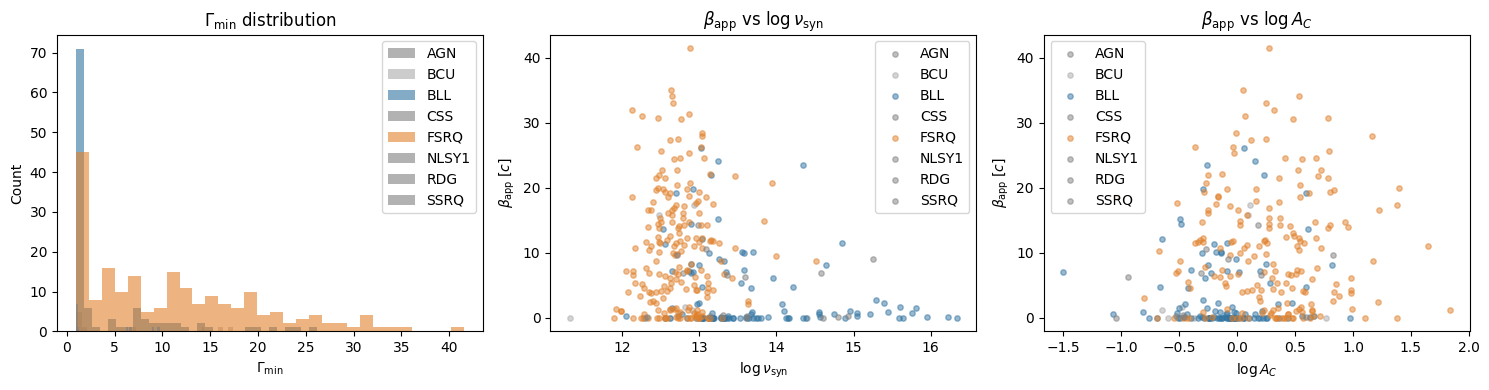

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

CLASS_COLORS = {"bll": "#3274a1", "fsrq": "#e1812c", "bcu": "#aaaaaa"}

# 1. gamma_min by CLASS
ax = axes[0]
for cls, grp in p2.groupby("class"):
    ax.hist(
        grp["gamma_min"],
        bins=30,
        alpha=0.6,
        label=cls.upper(),
        color=CLASS_COLORS.get(cls, "gray"),
    )
ax.set_xlabel(r"$\Gamma_{\rm min}$")
ax.set_ylabel("Count")
ax.set_title(r"$\Gamma_{\rm min}$ distribution")
ax.legend()

# 2. beta_app vs log_nu_syn
ax = axes[1]
for cls, grp in p2.groupby("class"):
    ax.scatter(
        grp["log_nu_syn"],
        grp["beta_app"],
        s=15,
        alpha=0.5,
        label=cls.upper(),
        color=CLASS_COLORS.get(cls, "gray"),
    )
ax.set_xlabel(r"$\log \nu_{\rm syn}$")
ax.set_ylabel(r"$\beta_{\rm app}\;[c]$")
ax.set_title(r"$\beta_{\rm app}$ vs $\log\nu_{\rm syn}$")
ax.legend()

# 3. beta_app vs log_compton_dom
ax = axes[2]
for cls, grp in p2.groupby("class"):
    ax.scatter(
        grp["log_compton_dom"],
        grp["beta_app"],
        s=15,
        alpha=0.5,
        label=cls.upper(),
        color=CLASS_COLORS.get(cls, "gray"),
    )
ax.set_xlabel(r"$\log A_C$")
ax.set_ylabel(r"$\beta_{\rm app}\;[c]$")
ax.set_title(r"$\beta_{\rm app}$ vs $\log A_C$")
ax.legend()

plt.tight_layout()
plt.show()